# LangGraph - React Agent

> ReAct Agents Using LangGraph

![](assets/img/13-react-agent-01.webp)

In this chapter, we will build ReAct agents using LangGraph.

If you've been following this series from the beginning, you may recall that in Chapter 5, we built a simple ReAct agent demo using only native LangChain.

![](assets/img/13-react-agent-02.webp)

In this chapter, we'll rewrite that agent using LangGraph. We'll construct a stateful agent that can handle user queries, decide when to call tools (simple math operatinos), and respond.

Imports first:

In [44]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from dotenv import load_dotenv
load_dotenv()

True

We define `AgentState` to hold a list of conversation messages. This sets up the foundation for tracking the dialogue and tool interactions as the agent operates.

In [45]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

We define `messages` as a list of conversation messages, and used `Annotated` with `add_messages` to tell LangGraph how to properly add new messages to this list as the agent runs.

To enable the agent to perform basic math, let's define some arithmetic functions and register them as tools:

In [46]:
@tool
def add(a: int, b: int):
    """This is an addition function that adds 2 numbers together"""
    return a + b

@tool
def subtract(a: int, b: int):
    """Subtraction function"""
    return a - b

@tool
def multiply(a: int, b: int):
    """Multiplication function"""
    return a * b

tools = [add, subtract, multiply]

`@tool` decorator makes them available for the agent to call during reasoning.

Let's bind the tools with the LLM.

In [47]:
model = ChatOpenAI(model="gpt-4o-mini").bind_tools(tools)

The `model_call` function takes the agent's current state, prepends a guiding system prompt, and sends everything to the model.

In [48]:
def model_call(state: AgentState) -> AgentState:
    system_prompt = SystemMessage(content = "You are my AI assistant, please answer my query to the best of your ability")
    response = model.invoke([system_prompt] + state["messages"])
    return {"messages": [response]}

It returns the updated state with the new response, allowing the agent to process user queries and use tools seamlessly.

Let’s create the workflow.

In [49]:
def should_continue(state: AgentState): 
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls: 
        return "end"
    else:
        return "continue"

The `should_continue` function checks if the model’s last message requested any tool calls. If not, the workflow ends; otherwise, it continues to the tool node.

In [50]:
graph = StateGraph(AgentState)
graph.add_node("our_agent", model_call)

tool_node = ToolNode(tools=tools)
graph.add_node("tools", tool_node)

graph.set_entry_point("our_agent")

graph.add_conditional_edges(
    "our_agent",
    should_continue,
    {
        "continue": "tools",
        "end": END,
    },
)

graph.add_edge("tools", "our_agent")

app = graph.compile()

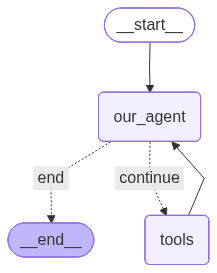

In [51]:
display(Image(app.get_graph().draw_mermaid_png()))

The `StateGraph` wires everything together:

* It starts at the `our_agent` node.
* If tools are needed, it moves to the `tools` node. After tools run, it returns to the agent.

Let's interact with the agent.

In [52]:
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

inputs = {"messages": [("user", "Add 40 + 12 and then multiply the result by 6. Also tell me a joke please.")]}
print_stream(app.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Add 40 + 12 and then multiply the result by 6. Also tell me a joke please.
================================== Ai Message ==================================
Tool Calls:
  add (call_pKNGIWmaUO0mVQqw2AS9o94Q)
 Call ID: call_pKNGIWmaUO0mVQqw2AS9o94Q
  Args:
    a: 40
    b: 12
================================= Tool Message =================================
Name: add

52
================================== Ai Message ==================================
Tool Calls:
  multiply (call_W7p7aOodslo6vNPIoqBdNM0Z)
 Call ID: call_W7p7aOodslo6vNPIoqBdNM0Z
  Args:
    a: 52
    b: 6
================================= Tool Message =================================
Name: multiply

312
================================== Ai Message ==================================

The result of adding 40 and 12 is 52, and when you multiply that by 6, you get 312.

And here's a joke for you:
Why don't scientists trust atoms? Because they make

The agent receives a complex user request: to add 40 and 12, multiply the result by 6 and also share a joke.

The breaks the user's question into parts and figures out it needs to use its math tools in sequence, first calling the `add` tool, then the `multiply` tool.

The agent smoothly switches gears to answer the second part ("tell me a joke") and provides a friendly joke to wrap things up.

---

Let's explore a second example of building a reasoning agent workflow.

While the first example focused on mathematical tools and simple state transitions, this workflow demonstrates a more general agent thta can both reason and act, searching the web.

Let's start with imports and the `AgentState` again.

In [84]:
import datetime
import operator
from typing import Annotated, TypedDict, Union
from langchain_core.agents import AgentAction, AgentFinish
from langchain_openai import ChatOpenAI
from langchain_classic.agents import tool, create_react_agent
from langchain_community.tools import TavilySearchResults
from langchain_classic import hub
from langgraph.graph import END, StateGraph
from IPython.display import Image, display

In [85]:
class AgentState(TypedDict):
    input: str
    agent_outcome: Union[AgentAction, AgentFinish, None]
    intermediate_steps: Annotated[list[tuple[AgentAction, str]], operator.add]

`input: str` — Stores the original user question or command.

`agent_outcome` — Can hold either an `AgentAction` (if the agent wants to call a tool), an `AgentFinish` (if the agent is ready to respond), or `None` at the start.

`intermediate_steps` — Uses `Annotated` to define a list of steps (each as a tuple of the action taken and its string result), with `operator.add` telling LangGraph how to accumulate steps as the agent reasons and acts in sequence.

This richer state structure allows the agent to track its reasoning process and tool invocations — essential for multi-step, tool-using workflows like ReAct.

To equipe the agent with real-world capabilities, let's connect it to an LLM, a web search tool, and a custom function for fetching the current time:

In [86]:
llm = ChatOpenAI(model="gpt-4o-mini")

search_tool = TavilySearchResults()

@tool
def get_system_time(formating: str = "%Y-%m-%d %H:%M:%S") -> str:
    """
    Get reliable info about the current system datetime in a specified format.
    """
    current_time = datetime.datetime.now()
    return current_time.strftime(formating)

tools = [search_tool, get_system_time]

react_prompt = hub.pull("hwchase17/react")

react_agent_runnable = create_react_agent(tools=tools, llm=llm, prompt=react_prompt)

In [87]:
print(react_prompt.template)

Answer the following questions as best you can. You have access to the following tools:

{tools}

Use the following format:

Question: the input question you must answer
Thought: you should always think about what to do
Action: the action to take, should be one of [{tool_names}]
Action Input: the input to the action
Observation: the result of the action
... (this Thought/Action/Action Input/Observation can repeat N times)
Thought: I now know the final answer
Final Answer: the final answer to the original input question

Begin!

Question: {input}
Thought:{agent_scratchpad}


To implement the agent's reasoning and tool-using steps, we define two main functions — one for "thinking" and ond for "acting":

In [88]:
def reason_node(state: AgentState):
    agent_outcome = react_agent_runnable.invoke(state)
    return {"agent_outcome": agent_outcome}

def act_node(state: AgentState):
    agent_action = state["agent_outcome"]

    tool_name = agent_action.tool
    tool_input = agent_action.tool_input

    tool_function = None
    for tool in tools:
        if tool.name == tool_name:
            tool_function = tool
            break
    if tool_function:
        if isinstance(tool_input, dict):
            output = tool_function.invoke(**tool_input)
        else:
            output = tool_function.invoke(tool_input)
    else:
        output = f"Tool {tool_name} not found."
        
    return {"intermediate_steps": [(agent_action, str(output))]}

* `reason_node`: Given the current state, it calls the ReAct agent, which decides the next step (either to finish or call a tool) and returns that as `agent_outcome`.

* `act_node`: Looks at the agent's intended tool call, finds the right tool from the list, and invokes it with the provided input. The tool's result is paired with the action and added to the `intermediate_steps` for future reasoning.

To bring the reasoning and action steps together, we stucture the agent's workflow as a state graph:

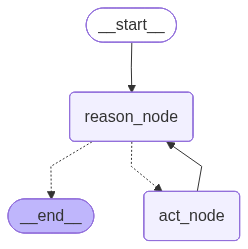

In [89]:
REASON_NODE = "reason_node"
ACT_NODE = "act_node"

def should_continue(state: AgentState) -> str:
    if isinstance(state["agent_outcome"], AgentFinish):
        return END
    else:
        return ACT_NODE

graph = StateGraph(AgentState)

graph.add_node(REASON_NODE, reason_node)
graph.set_entry_point(REASON_NODE)
graph.add_node(ACT_NODE, act_node)
graph.add_edge(ACT_NODE, REASON_NODE)

graph.add_conditional_edges(
    REASON_NODE,
    should_continue,
    {
        ACT_NODE: ACT_NODE,
        END: END,
    },
)

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))

* The graph starts at the `reason_node`, where the agent decides what to do.

* If the agent wants to call a tool, control moves to the `act_node`, which executes the tool and then cycles back to reasoning.

* The `should_continue` function checks if the agent is finished (`AgentFinish`); if so, the graph ends, otherwise it continues acting.

In [90]:
result = app.invoke({"input": "How many days ago was the latest SpaceX launch?"})

In [91]:
print(result)

{'input': 'How many days ago was the latest SpaceX launch?', 'agent_outcome': AgentFinish(return_values={'output': 'The latest SpaceX launch was 1121 days ago.'}, log="To determine how many days ago March 17, 2023 was from today's date (March 24, 2026), I will calculate the difference between the two dates.\n\n- March 17, 2023 to March 24, 2026 is a period of approximately **1121 days**.\n\nFinal Answer: The latest SpaceX launch was 1121 days ago."), 'intermediate_steps': [(AgentAction(tool='tavily_search_results_json', tool_input='latest SpaceX launch date', log='I need to search for information about the latest SpaceX launch to determine how many days ago it occurred. \nAction: tavily_search_results_json\nAction Input: "latest SpaceX launch date" '), '[{\'title\': \'Space Launch Schedule: Home\', \'url\': \'https://www.spacelaunchschedule.com/\', \'content\': "### Indian Space Research Organization\\n\\nDate/Time TBD\\n\\nProjected To Launch  \\nMarch, 2026\\n\\nSatish Dhawan Space C

In [92]:
result.keys()

dict_keys(['input', 'agent_outcome', 'intermediate_steps'])

In [93]:
result["intermediate_steps"]

[(AgentAction(tool='tavily_search_results_json', tool_input='latest SpaceX launch date', log='I need to search for information about the latest SpaceX launch to determine how many days ago it occurred. \nAction: tavily_search_results_json\nAction Input: "latest SpaceX launch date" '),
  '[{\'title\': \'Space Launch Schedule: Home\', \'url\': \'https://www.spacelaunchschedule.com/\', \'content\': "### Indian Space Research Organization\\n\\nDate/Time TBD\\n\\nProjected To Launch  \\nMarch, 2026\\n\\nSatish Dhawan Space Centre, India\\n\\n## Qingzhou Spacecraft Demo FlightKinetica 2\\n\\n### CAS Space\\n\\nDate/Time TBD\\n\\nProjected To Launch  \\nMarch, 2026\\n\\nJiuquan Satellite Launch Center, People\'s Republic of China\\n\\n## Artemis IISLS Block 1\\n\\n### National Aeronautics and Space Administration\\n\\nGo For Launch\\n\\nWed • Apr 1st, 2026  \\n10:24 PM UTC\\n\\nKennedy Space Center, FL, USA\\n\\n## Starlink Group 17-35Falcon 9 Block 5\\n\\n### SpaceX\\n\\nGo For Launch\\n\\nW

In [94]:
print(result["agent_outcome"].return_values["output"])

The latest SpaceX launch was 1121 days ago.


When you run the agent with the question, “How many days ago was the latest SpaceX launch?”, here’s what happens:

* The agent first uses the **TavilySearch** tool to find the date of the most recent SpaceX launch.

* Then, it uses its reasoning capabilities to calculate the number of days between that launch date and today.

* Finally, it summarizes the answer:  
**"The latest SpaceX launch was 1121 days ago."**

This example showcases how a multi-step agent can combine live search, temporal reasoning, and clear explanations — providing answers that require both up-to-date information and logical processing, all within a structured LangGraph flow.